In [17]:
import warnings
warnings.filterwarnings("ignore")

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix

pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", "{:,.6f}".format)

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.config import (
    RAW_DATA_DIR,
    PROCESSED_DATA_DIR,
    FIGURES_DIR,
    REPORTS_DIR,
    TARGET_COL,
    ID_COL,
)

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

ERROR_ANALYSIS_FIG_DIR = FIGURES_DIR / "error_analysis"
ERROR_ANALYSIS_FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Figure folder:", ERROR_ANALYSIS_FIG_DIR)

Figure folder: C:\Coding\Home-Credit-Default-Risk\outputs\figures\error_analysis


In [18]:
def find_first_existing(base_dir, candidates):
    for name in candidates:
        path = base_dir / name
        if path.exists():
            return path
    raise FileNotFoundError(f"None of these files were found in {base_dir}: {candidates}")

In [19]:
oof_path = find_first_existing(
    REPORTS_DIR,
    [
        "model_v4_with_payments_oof.csv",
        "full_model_oof.csv",
    ],
)

importance_path = find_first_existing(
    REPORTS_DIR,
    [
        "model_v4_with_payments_feature_importance.csv",
        "full_model_feature_importance.csv",
    ],
)

bureau_path = find_first_existing(
    PROCESSED_DATA_DIR,
    [
        "bureau_features.parquet",
    ],
)

previous_path = find_first_existing(
    PROCESSED_DATA_DIR,
    [
        "previous_application_features.parquet",
        "previous_features.parquet",
    ],
)

payment_path = find_first_existing(
    PROCESSED_DATA_DIR,
    [
        "payment_history_features.parquet",
    ],
)

print("OOF file       :", oof_path.name)
print("Importance file:", importance_path.name)
print("Bureau file    :", bureau_path.name)
print("Previous file  :", previous_path.name)
print("Payment file   :", payment_path.name)

OOF file       : model_v4_with_payments_oof.csv
Importance file: model_v4_with_payments_feature_importance.csv
Bureau file    : bureau_features.parquet
Previous file  : previous_application_features.parquet
Payment file   : payment_history_features.parquet


In [20]:
train = pd.read_csv(RAW_DATA_DIR / "application_train.csv")
oof_df = pd.read_csv(oof_path)
importance_df = pd.read_csv(importance_path)

bureau_features = pd.read_parquet(bureau_path)
previous_features = pd.read_parquet(previous_path)
payment_features = pd.read_parquet(payment_path)

print("Train shape:", train.shape)
print("OOF shape:", oof_df.shape)
print("Importance shape:", importance_df.shape)
print("Bureau features shape:", bureau_features.shape)
print("Previous features shape:", previous_features.shape)
print("Payment features shape:", payment_features.shape)

Train shape: (307511, 122)
OOF shape: (307511, 3)
Importance shape: (308, 2)
Bureau features shape: (356255, 37)
Previous features shape: (356255, 39)
Payment features shape: (356255, 115)


In [21]:
analysis_df = (
    train
    .merge(oof_df[[ID_COL, "OOF_PRED"]], on=ID_COL, how="left")
    .merge(bureau_features, on=ID_COL, how="left")
    .merge(previous_features, on=ID_COL, how="left")
    .merge(payment_features, on=ID_COL, how="left")
)

if "TARGET_x" in analysis_df.columns:
    analysis_df[TARGET_COL] = analysis_df["TARGET_x"]
    drop_cols = [c for c in ["TARGET_x", "TARGET_y"] if c in analysis_df.columns]
    analysis_df = analysis_df.drop(columns=drop_cols)

print("Analysis dataframe shape:", analysis_df.shape)
print("Missing OOF predictions:", analysis_df["OOF_PRED"].isnull().sum())

display(analysis_df.head())

Analysis dataframe shape: (307511, 311)
Missing OOF predictions: 0


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,...,INS_UNDERPAID_COUNT,INS_UNDERPAID_RATIO,INS_OVERPAID_COUNT,INS_OVERPAID_RATIO,INS_PAYMENT_RATIO_MEAN,INS_PAYMENT_RATIO_MIN,INS_PAYMENT_RATIO_MAX,INS_PAYMENT_DIFF_MEAN,INS_PAYMENT_DIFF_MIN,INS_PAYMENT_DIFF_MAX,INS_PAYMENT_DIFF_SUM,INS_AMT_PAYMENT_SUM,INS_AMT_PAYMENT_MEAN,INS_AMT_INSTALMENT_SUM,INS_AMT_INSTALMENT_MEAN,INS_DAYS_INSTALMENT_MIN,INS_DAYS_INSTALMENT_MAX,INS_DAYS_ENTRY_PAYMENT_MIN,INS_DAYS_ENTRY_PAYMENT_MAX,INS_TOTAL_PAYMENT_TO_INSTALMENT_RATIO,POS_SK_ID_PREV_NUNIQUE,POS_RECORD_COUNT,POS_MONTHS_BALANCE_MIN,POS_MONTHS_BALANCE_MAX,POS_MONTHS_BALANCE_SIZE,POS_CNT_INSTALMENT_MEAN,POS_CNT_INSTALMENT_MAX,POS_CNT_INSTALMENT_FUTURE_MEAN,POS_CNT_INSTALMENT_FUTURE_MAX,POS_SK_DPD_MEAN,POS_SK_DPD_MAX,POS_SK_DPD_DEF_MEAN,POS_SK_DPD_DEF_MAX,POS_DPD_COUNT,POS_DPD_RATIO,POS_DPD_DEF_COUNT,POS_DPD_DEF_RATIO,POS_STATUS_ACTIVE_COUNT,POS_STATUS_COMPLETED_COUNT,POS_STATUS_SIGNED_COUNT,POS_STATUS_DEMAND_COUNT,POS_STATUS_ACTIVE_RATIO,POS_STATUS_COMPLETED_RATIO,POS_STATUS_SIGNED_RATIO,POS_STATUS_DEMAND_RATIO,CC_SK_ID_PREV_NUNIQUE,CC_RECORD_COUNT,CC_MONTHS_BALANCE_MIN,CC_MONTHS_BALANCE_MAX,CC_MONTHS_BALANCE_SIZE,CC_AMT_BALANCE_MEAN,CC_AMT_BALANCE_MAX,CC_AMT_BALANCE_SUM,CC_AMT_CREDIT_LIMIT_ACTUAL_MEAN,CC_AMT_CREDIT_LIMIT_ACTUAL_MAX,CC_BALANCE_LIMIT_RATIO_MEAN,CC_BALANCE_LIMIT_RATIO_MAX,CC_AMT_DRAWINGS_CURRENT_MEAN,CC_AMT_DRAWINGS_CURRENT_MAX,CC_AMT_DRAWINGS_CURRENT_SUM,CC_DRAWINGS_LIMIT_RATIO_MEAN,CC_DRAWINGS_LIMIT_RATIO_MAX,CC_AMT_PAYMENT_CURRENT_MEAN,CC_AMT_PAYMENT_CURRENT_MAX,CC_AMT_PAYMENT_CURRENT_SUM,CC_AMT_PAYMENT_TOTAL_CURRENT_MEAN,CC_AMT_PAYMENT_TOTAL_CURRENT_MAX,CC_AMT_PAYMENT_TOTAL_CURRENT_SUM,CC_AMT_INST_MIN_REGULARITY_MEAN,CC_AMT_INST_MIN_REGULARITY_MAX,CC_PAYMENT_MIN_RATIO_MEAN,CC_PAYMENT_MIN_RATIO_MAX,CC_TOTAL_PAYMENT_BALANCE_RATIO_MEAN,CC_TOTAL_PAYMENT_BALANCE_RATIO_MAX,CC_CNT_DRAWINGS_CURRENT_MEAN,CC_CNT_DRAWINGS_CURRENT_MAX,CC_CNT_DRAWINGS_ATM_CURRENT_MEAN,CC_CNT_DRAWINGS_POS_CURRENT_MEAN,CC_CNT_INSTALMENT_MATURE_CUM_MEAN,CC_CNT_INSTALMENT_MATURE_CUM_MAX,CC_SK_DPD_MEAN,CC_SK_DPD_MAX,CC_SK_DPD_DEF_MEAN,CC_SK_DPD_DEF_MAX,CC_DPD_COUNT,CC_DPD_RATIO,CC_DPD_DEF_COUNT,CC_DPD_DEF_RATIO,CC_BALANCE_POSITIVE_COUNT,CC_BALANCE_POSITIVE_RATIO,CC_PAYMENT_LESS_THAN_MIN_COUNT,CC_PAYMENT_LESS_THAN_MIN

In [22]:
oof_auc = roc_auc_score(analysis_df[TARGET_COL], analysis_df["OOF_PRED"])
print(f"OOF AUC: {oof_auc:.6f}")

fpr, tpr, thresholds = roc_curve(analysis_df[TARGET_COL], analysis_df["OOF_PRED"])
youden_j = tpr - fpr
best_idx = np.argmax(youden_j)
best_threshold = thresholds[best_idx]

print(f"Best threshold by Youden's J: {best_threshold:.6f}")

OOF AUC: 0.785274
Best threshold by Youden's J: 0.464240


In [23]:
analysis_df["PRED_LABEL"] = (analysis_df["OOF_PRED"] >= best_threshold).astype(int)

conditions = [
    (analysis_df[TARGET_COL] == 1) & (analysis_df["PRED_LABEL"] == 1),
    (analysis_df[TARGET_COL] == 0) & (analysis_df["PRED_LABEL"] == 0),
    (analysis_df[TARGET_COL] == 0) & (analysis_df["PRED_LABEL"] == 1),
    (analysis_df[TARGET_COL] == 1) & (analysis_df["PRED_LABEL"] == 0),
]

choices = [
    "True Positive",
    "True Negative",
    "False Positive",
    "False Negative",
]

analysis_df["ERROR_GROUP"] = np.select(conditions, choices, default="Unknown")

error_counts = analysis_df["ERROR_GROUP"].value_counts().reindex(
    ["True Negative", "False Positive", "False Negative", "True Positive"]
)

print("Error group counts:")
display(error_counts)

cm = confusion_matrix(analysis_df[TARGET_COL], analysis_df["PRED_LABEL"])
print("Confusion matrix:")
print(cm)

Error group counts:


ERROR_GROUP
True Negative     200828
False Positive     81858
False Negative      6938
True Positive      17887
Name: count, dtype: int64

Confusion matrix:
[[200828  81858]
 [  6938  17887]]


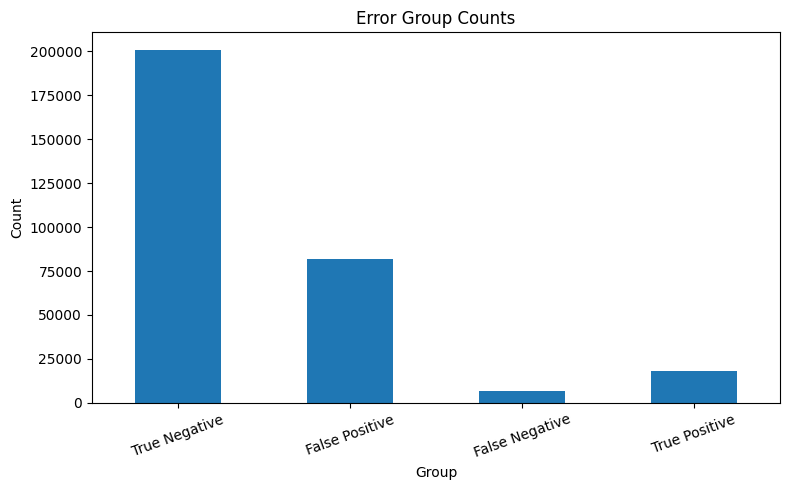

Saved: C:\Coding\Home-Credit-Default-Risk\outputs\figures\error_analysis\01_error_group_counts.png


In [24]:
plt.figure(figsize=(8, 5))
error_counts.plot(kind="bar")
plt.title("Error Group Counts")
plt.xlabel("Group")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.tight_layout()

error_group_fig = ERROR_ANALYSIS_FIG_DIR / "01_error_group_counts.png"
plt.savefig(error_group_fig, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", error_group_fig)

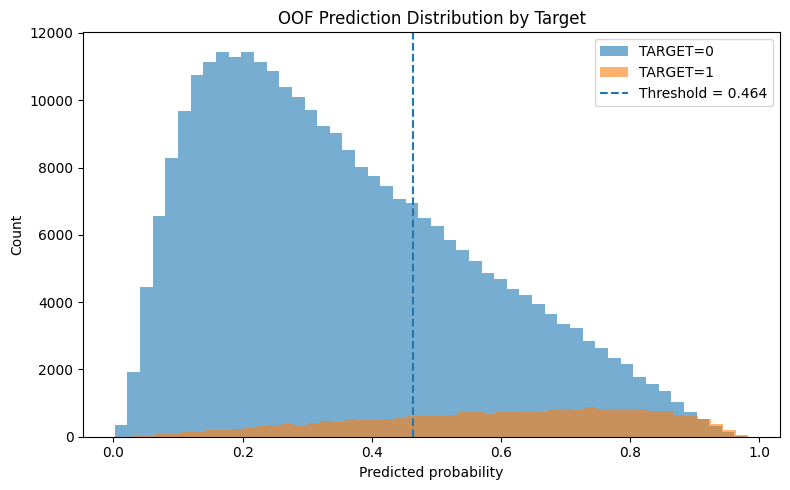

Saved: C:\Coding\Home-Credit-Default-Risk\outputs\figures\error_analysis\02_oof_prediction_distribution.png


In [25]:
plt.figure(figsize=(8, 5))

plt.hist(
    analysis_df.loc[analysis_df[TARGET_COL] == 0, "OOF_PRED"].dropna(),
    bins=50,
    alpha=0.6,
    label="TARGET=0"
)

plt.hist(
    analysis_df.loc[analysis_df[TARGET_COL] == 1, "OOF_PRED"].dropna(),
    bins=50,
    alpha=0.6,
    label="TARGET=1"
)

plt.axvline(best_threshold, linestyle="--", label=f"Threshold = {best_threshold:.3f}")
plt.title("OOF Prediction Distribution by Target")
plt.xlabel("Predicted probability")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()

pred_dist_fig = ERROR_ANALYSIS_FIG_DIR / "02_oof_prediction_distribution.png"
plt.savefig(pred_dist_fig, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", pred_dist_fig)

In [26]:
importance_df = importance_df.sort_values("importance", ascending=False).reset_index(drop=True)
top_features = importance_df.head(30).copy()

display(top_features)

,feature,importance
0,EXT_SOURCE_3,8.769960
1,EXT_SOURCE_2,7.133875
2,EXT_SOURCE_1,3.924690
3,DAYS_BIRTH,3.192080
4,AMT_CREDIT,2.676793
5,AMT_ANNUITY,2.397871
6,AMT_GOODS_PRICE,2.199153
7,BUREAU_DEBT_CREDIT_RATIO_MEAN,1.837825
8,DAYS_EMPLOYED,1.721038
9,POS_CNT_INSTALMENT_FUTURE_MEAN,1.330537


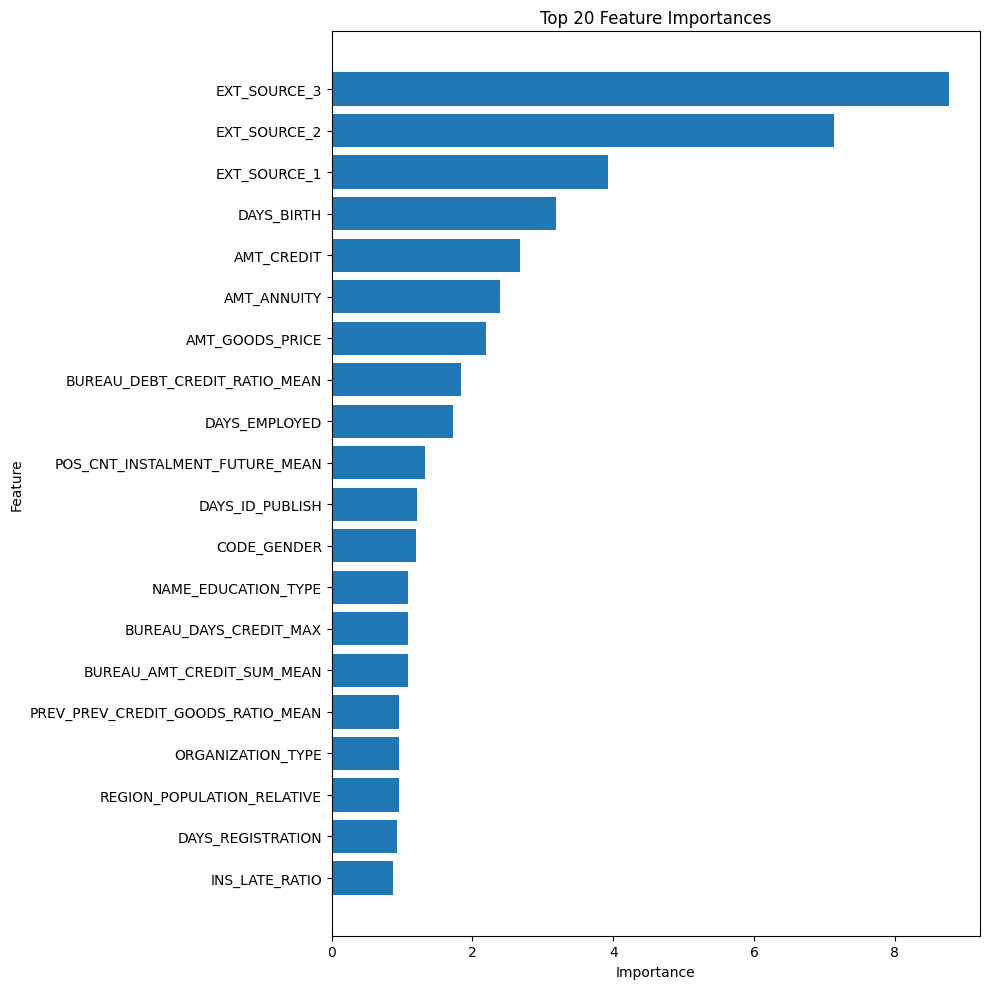

Saved: C:\Coding\Home-Credit-Default-Risk\outputs\figures\error_analysis\03_top_feature_importance.png


In [27]:
plot_df = top_features.head(20).sort_values("importance", ascending=True)

plt.figure(figsize=(10, 10))
plt.barh(plot_df["feature"], plot_df["importance"])
plt.title("Top 20 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()

importance_fig = ERROR_ANALYSIS_FIG_DIR / "03_top_feature_importance.png"
plt.savefig(importance_fig, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", importance_fig)

In [28]:
def feature_family(feature_name):
    name = str(feature_name).upper()
    if name.startswith("BURO") or name.startswith("BUREAU"):
        return "bureau"
    if name.startswith("PREV"):
        return "previous_application"
    if name.startswith("INS") or name.startswith("POS") or name.startswith("CC"):
        return "payment_history"
    return "main_application"

family_df = importance_df.head(50).copy()
family_df["feature_family"] = family_df["feature"].apply(feature_family)

family_summary = (
    family_df.groupby("feature_family")
    .agg(
        top50_feature_count=("feature", "count"),
        top50_total_importance=("importance", "sum"),
        top50_mean_importance=("importance", "mean"),
    )
    .sort_values("top50_total_importance", ascending=False)
    .reset_index()
)

display(family_summary)

,feature_family,top50_feature_count,top50_total_importance,top50_mean_importance
0,main_application,21,43.046229,2.049820
1,payment_history,15,10.007692,0.667179
2,bureau,7,6.512974,0.930425
3,previous_application,7,4.417790,0.631113


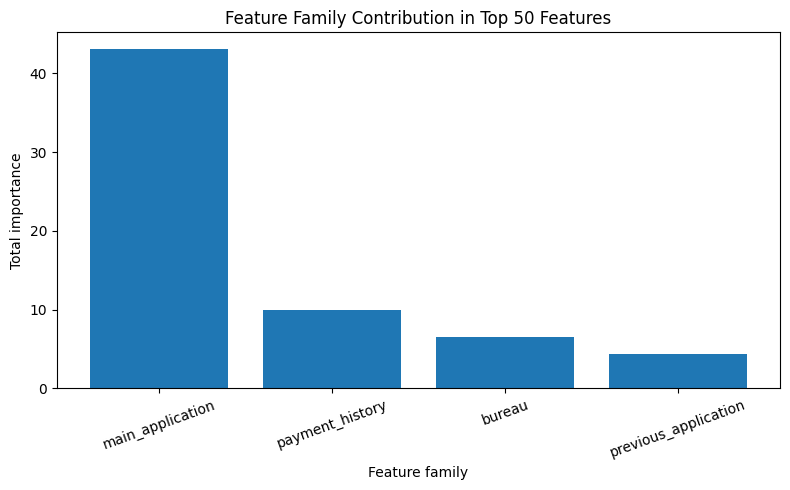

Saved: C:\Coding\Home-Credit-Default-Risk\outputs\figures\error_analysis\04_feature_family_contribution.png


In [29]:
plt.figure(figsize=(8, 5))
plt.bar(family_summary["feature_family"], family_summary["top50_total_importance"])
plt.title("Feature Family Contribution in Top 50 Features")
plt.xlabel("Feature family")
plt.ylabel("Total importance")
plt.xticks(rotation=20)
plt.tight_layout()

family_fig = ERROR_ANALYSIS_FIG_DIR / "04_feature_family_contribution.png"
plt.savefig(family_fig, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", family_fig)

In [30]:
if "DAYS_BIRTH" in analysis_df.columns:
    analysis_df["AGE_YEARS"] = (-analysis_df["DAYS_BIRTH"] / 365).round(2)

if "DAYS_EMPLOYED" in analysis_df.columns:
    employed = analysis_df["DAYS_EMPLOYED"].replace(365243, np.nan)
    analysis_df["EMPLOYMENT_YEARS"] = (-employed / 365).round(2)

helper_cols = [c for c in ["AGE_YEARS", "EMPLOYMENT_YEARS"] if c in analysis_df.columns]
display(analysis_df[helper_cols].head())

,AGE_YEARS,EMPLOYMENT_YEARS
0,25.920000,1.750000
1,45.930000,3.250000
2,52.180000,0.620000
3,52.070000,8.330000
4,54.610000,8.320000


In [31]:
candidate_cols = [
    "EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3",
    "AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY",
    "AGE_YEARS", "EMPLOYMENT_YEARS",
    "CNT_CHILDREN", "DAYS_EMPLOYED",
    "BURO_ACTIVE_RATIO", "BURO_AMT_CREDIT_SUM_DEBT_SUM",
    "PREV_APPROVED_RATIO", "PREV_REFUSED_RATIO",
    "INS_LATE_RATIO", "INS_DPD_MEAN",
    "POS_DPD_RATIO", "POS_DPD_DEF_RATIO",
    "CC_DPD_RATIO", "CC_BALANCE_LIMIT_RATIO_MEAN", "CC_PAYMENT_MIN_RATIO_MEAN",
]

existing_candidate_cols = [c for c in candidate_cols if c in analysis_df.columns]

top_numeric_features = [
    c for c in importance_df["feature"].tolist()
    if c in analysis_df.columns and pd.api.types.is_numeric_dtype(analysis_df[c])
]

for col in top_numeric_features:
    if col not in existing_candidate_cols:
        existing_candidate_cols.append(col)
    if len(existing_candidate_cols) >= 20:
        break

group_mean_table = (
    analysis_df.groupby("ERROR_GROUP")[existing_candidate_cols]
    .mean()
    .T
    .reset_index()
    .rename(columns={"index": "feature"})
)

display(group_mean_table.head(30))

ERROR_GROUP,feature,False Negative,False Positive,True Negative,True Positive
0,EXT_SOURCE_1,0.506909,0.368312,0.561836,0.333700
1,EXT_SOURCE_2,0.543612,0.403105,0.572504,0.359518
2,EXT_SOURCE_3,0.535534,0.375649,0.574443,0.329473
3,AMT_INCOME_TOTAL,"170,517.014702","158,971.600153","173,197.003162","163,709.113686"
4,AMT_CREDIT,"627,949.717498","546,966.520267","625,344.308712","530,560.564069"
5,AMT_ANNUITY,"27,409.608965","26,105.399197","27,594.946873","26,121.844636"
6,AGE_YEARS,45.035653,39.896015,45.974282,39.129808
7,EMPLOYMENT_YEARS,6.789976,4.666967,7.620159,4.362207
8,CNT_CHILDREN,0.391179,0.478218,0.386341,0.491977
9,DAYS_EMPLOYED,"74,373.191842","36,525.189902","77,586.301552","29,990.865601"


In [32]:
group_mean_path = REPORTS_DIR / "error_group_feature_means.csv"
group_mean_table.to_csv(group_mean_path, index=False)

print("Saved:", group_mean_path)

Saved: C:\Coding\Home-Credit-Default-Risk\outputs\reports\error_group_feature_means.csv


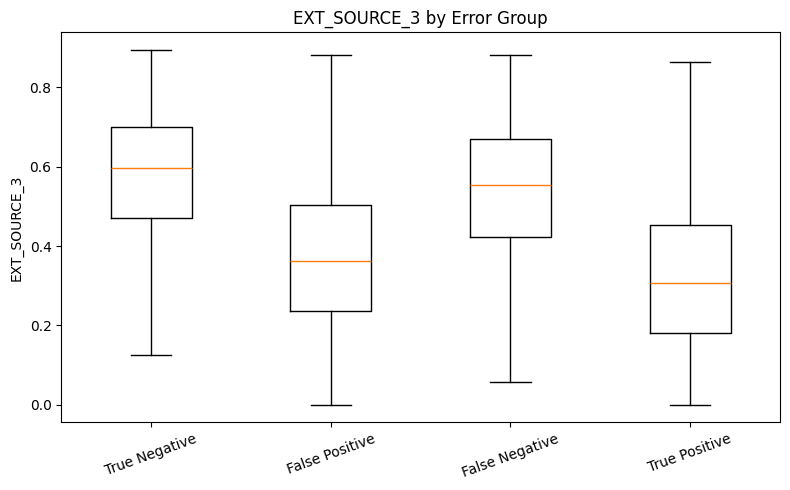

Saved: C:\Coding\Home-Credit-Default-Risk\outputs\figures\error_analysis\05_error_slice_EXT_SOURCE_3.png


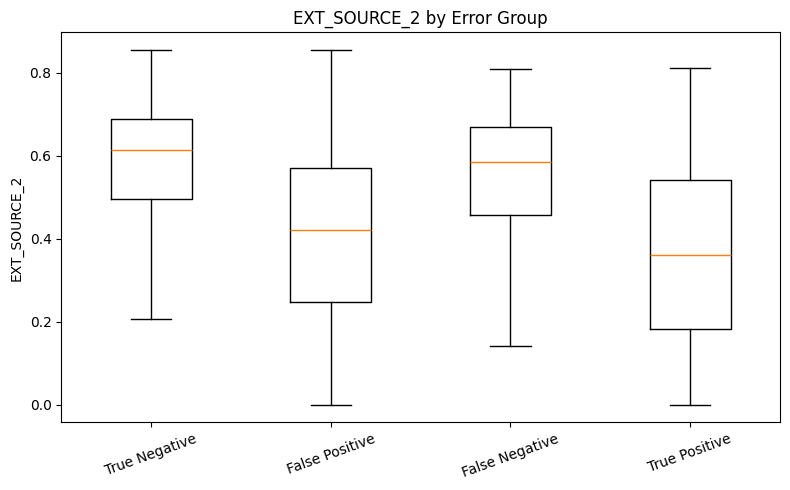

Saved: C:\Coding\Home-Credit-Default-Risk\outputs\figures\error_analysis\06_error_slice_EXT_SOURCE_2.png


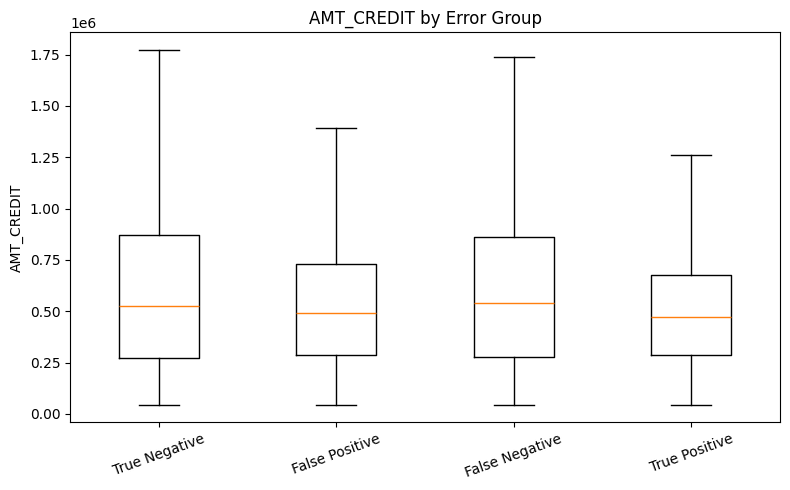

Saved: C:\Coding\Home-Credit-Default-Risk\outputs\figures\error_analysis\07_error_slice_AMT_CREDIT.png


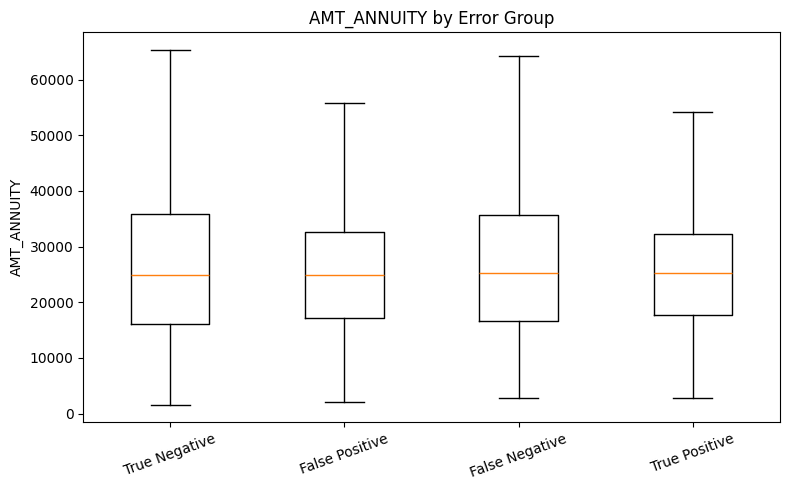

Saved: C:\Coding\Home-Credit-Default-Risk\outputs\figures\error_analysis\08_error_slice_AMT_ANNUITY.png


In [33]:
plot_candidates = [
    "EXT_SOURCE_3",
    "EXT_SOURCE_2",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AGE_YEARS",
    "INS_LATE_RATIO",
    "POS_DPD_RATIO",
    "CC_DPD_RATIO",
]

plot_candidates = [c for c in plot_candidates if c in analysis_df.columns][:4]

for i, feature in enumerate(plot_candidates, start=5):
    temp = analysis_df[[feature, "ERROR_GROUP"]].dropna().copy()
    groups = ["True Negative", "False Positive", "False Negative", "True Positive"]
    data = [temp.loc[temp["ERROR_GROUP"] == g, feature].values for g in groups]

    plt.figure(figsize=(8, 5))
    plt.boxplot(data, labels=groups, showfliers=False)
    plt.title(f"{feature} by Error Group")
    plt.ylabel(feature)
    plt.xticks(rotation=20)
    plt.tight_layout()

    fig_path = ERROR_ANALYSIS_FIG_DIR / f"{i:02d}_error_slice_{feature}.png"
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.show()

    print("Saved:", fig_path)

In [34]:
false_negatives = (
    analysis_df.loc[analysis_df["ERROR_GROUP"] == "False Negative"]
    .sort_values("OOF_PRED", ascending=True)
    .head(20)
)

false_positives = (
    analysis_df.loc[analysis_df["ERROR_GROUP"] == "False Positive"]
    .sort_values("OOF_PRED", ascending=False)
    .head(20)
)

cols_to_show = [c for c in [
    ID_COL, TARGET_COL, "OOF_PRED",
    "EXT_SOURCE_2", "EXT_SOURCE_3",
    "AMT_CREDIT", "AMT_ANNUITY", "AMT_INCOME_TOTAL",
    "AGE_YEARS", "INS_LATE_RATIO", "POS_DPD_RATIO", "CC_DPD_RATIO"
] if c in analysis_df.columns]

display(false_negatives[cols_to_show])
display(false_positives[cols_to_show])

,SK_ID_CURR,TARGET,OOF_PRED,EXT_SOURCE_2,EXT_SOURCE_3,AMT_CREDIT,AMT_ANNUITY,AMT_INCOME_TOTAL,AGE_YEARS,INS_LATE_RATIO,POS_DPD_RATIO,CC_DPD_RATIO
31365,136391,1,0.006973,0.730941,0.800451,"983,299.500000","39,123.000000","382,500.000000",46.990000,0.000000,0.000000,NaN
219787,354619,1,0.026868,0.629838,0.641368,"1,154,520.000000","45,913.500000","234,000.000000",58.870000,0.000000,0.000000,NaN
127110,247412,1,0.029701,0.669222,0.657784,"1,971,072.000000","68,643.000000","171,000.000000",40.950000,0.000000,0.000000,NaN
282120,426759,1,0.030111,0.732713,0.506484,"900,000.000000","24,133.500000","202,500.000000",54.180000,0.025000,0.000000,NaN
144318,267336,1,0.030549,0.722744,0.597192,"679,500.000000","64,647.000000","315,000.000000",57.940000,0.000000,0.000000,NaN
63150,173242,1,0.031740,0.809230,0.780144,"1,339,884.000000","36,976.500000","144,000.000000",63.150000,0.090909,0.029412,NaN
80664,193524,1,0.033959,0.749344,NaN,"1,009,566.000000","33,493.500000","112,500.000000",63.900000,0.000000,0.000000,NaN
106931,224059,1,0.036338,0.673953,0.598926,"1,575,000.000000","41,679.000000","225,000.000000",42.610000,0.000000,0.000000,NaN
189304,319477,1,0.036749,0.682870,0.604113,"203,760.000000","10,854.000000","202,500.000000",38.510000,0.042254,0.043478,0.021053
263579,405180,1,0.041722,0.730605,0.792264,"1,350,000.000000","53,662.500000","211,500.000000",47.750000,0.000000,0.000000,0.000000


,SK_ID_CURR,TARGET,OOF_PRED,EXT_SOURCE_2,EXT_SOURCE_3,AMT_CREDIT,AMT_ANNUITY,AMT_INCOME_TOTAL,AGE_YEARS,INS_LATE_RATIO,POS_DPD_RATIO,CC_DPD_RATIO
191099,321580,0,0.981161,0.010434,0.259468,"592,560.000000","31,153.500000","225,000.000000",31.340000,0.565217,0.642857,NaN
61584,171428,0,0.980153,0.011527,0.198620,"353,241.000000","28,039.500000","180,000.000000",38.420000,0.042553,0.000000,0.000000
44202,151205,0,0.979958,0.230625,0.151008,"521,280.000000","35,392.500000","112,500.000000",36.400000,0.216216,0.500000,0.000000
305538,453995,0,0.974355,0.197102,0.232725,"592,560.000000","35,937.000000","117,000.000000",32.990000,0.120000,0.000000,0.000000
126747,246993,0,0.972736,0.033586,0.185202,"521,280.000000","28,408.500000","99,000.000000",50.560000,0.111111,0.000000,0.000000
190527,320907,0,0.971664,0.066857,0.190706,"458,725.500000","42,201.000000","135,000.000000",32.130000,0.100000,0.000000,NaN
75978,188110,0,0.971588,0.630011,0.000527,"545,040.000000","25,407.000000","162,000.000000",39.860000,0.307692,0.000000,NaN
101809,218200,0,0.970881,0.000467,0.176653,"675,000.000000","41,296.500000","157,500.000000",47.540000,0.088235,0.055556,0.000000
193544,324442,0,0.970631,0.000221,0.210350,"315,000.000000","21,307.500000","112,500.000000",24.490000,0.500000,0.083333,NaN
66660,177300,0,0.970045,0.060446,0.025810,"592,560.000000","40,216.500000","135,000.000000",30.310000,0.333333,0.000000,NaN


In [35]:
fn_path = REPORTS_DIR / "hardest_false_negatives.csv"
fp_path = REPORTS_DIR / "hardest_false_positives.csv"

false_negatives[cols_to_show].to_csv(fn_path, index=False)
false_positives[cols_to_show].to_csv(fp_path, index=False)

print("Saved:", fn_path)
print("Saved:", fp_path)

Saved: C:\Coding\Home-Credit-Default-Risk\outputs\reports\hardest_false_negatives.csv
Saved: C:\Coding\Home-Credit-Default-Risk\outputs\reports\hardest_false_positives.csv


In [36]:
report_path = REPORTS_DIR / "error_analysis.md"

top10_features = importance_df.head(10)["feature"].tolist()

report_lines = [
    "# Error Analysis",
    "",
    "## Model quality",
    f"- OOF AUC: {oof_auc:.6f}",
    f"- Threshold used for error analysis: {best_threshold:.6f}",
    "",
    "## Error group counts",
]

for group_name, count in error_counts.items():
    report_lines.append(f"- {group_name}: {int(count)}")

report_lines += [
    "",
    "## Top 10 most important features",
]

for i, feature in enumerate(top10_features, start=1):
    value = importance_df.loc[importance_df["feature"] == feature, "importance"].iloc[0]
    report_lines.append(f"{i}. {feature} ({value:.6f})")

report_lines += [
    "",
    "## Feature family contribution in top 50",
]

for row in family_summary.itertuples(index=False):
    report_lines.append(
        f"- {row.feature_family}: count={row.top50_feature_count}, "
        f"total_importance={row.top50_total_importance:.6f}, "
        f"mean_importance={row.top50_mean_importance:.6f}"
    )

report_lines += [
    "",
    "## Files created",
    f"- {error_group_fig}",
    f"- {pred_dist_fig}",
    f"- {importance_fig}",
    f"- {family_fig}",
    f"- {group_mean_path}",
    f"- {fn_path}",
    f"- {fp_path}",
]

report_path.write_text("\n".join(report_lines), encoding="utf-8")

print("Saved:", report_path)
print(report_path.read_text(encoding="utf-8")[:2500])

Saved: C:\Coding\Home-Credit-Default-Risk\outputs\reports\error_analysis.md
# Error Analysis

## Model quality
- OOF AUC: 0.785274
- Threshold used for error analysis: 0.464240

## Error group counts
- True Negative: 200828
- False Positive: 81858
- False Negative: 6938
- True Positive: 17887

## Top 10 most important features
1. EXT_SOURCE_3 (8.769960)
2. EXT_SOURCE_2 (7.133875)
3. EXT_SOURCE_1 (3.924690)
4. DAYS_BIRTH (3.192080)
5. AMT_CREDIT (2.676793)
6. AMT_ANNUITY (2.397871)
7. AMT_GOODS_PRICE (2.199153)
8. BUREAU_DEBT_CREDIT_RATIO_MEAN (1.837825)
9. DAYS_EMPLOYED (1.721038)
10. POS_CNT_INSTALMENT_FUTURE_MEAN (1.330537)

## Feature family contribution in top 50
- main_application: count=21, total_importance=43.046229, mean_importance=2.049820
- payment_history: count=15, total_importance=10.007692, mean_importance=0.667179
- bureau: count=7, total_importance=6.512974, mean_importance=0.930425
- previous_application: count=7, total_importance=4.417790, mean_importance=0.631113

##

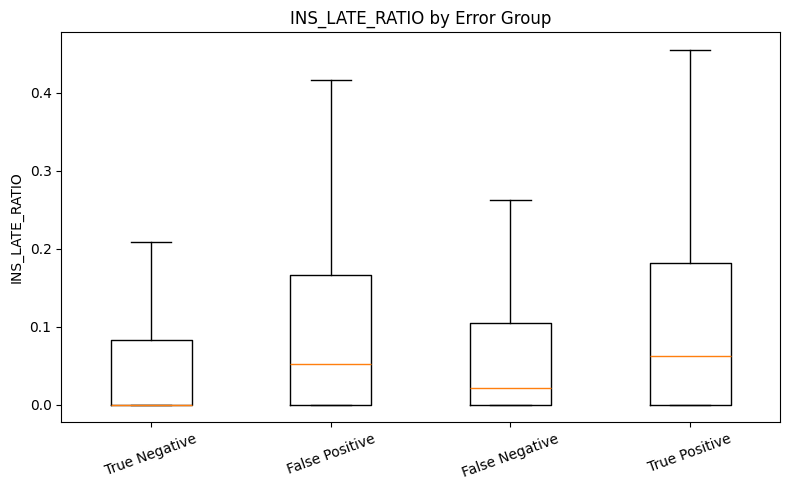

Saved: C:\Coding\Home-Credit-Default-Risk\outputs\figures\error_analysis\20_error_slice_INS_LATE_RATIO.png


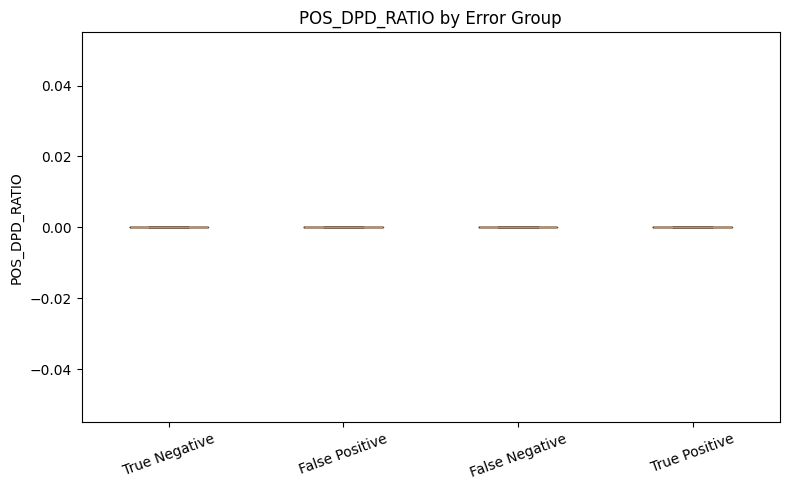

Saved: C:\Coding\Home-Credit-Default-Risk\outputs\figures\error_analysis\21_error_slice_POS_DPD_RATIO.png


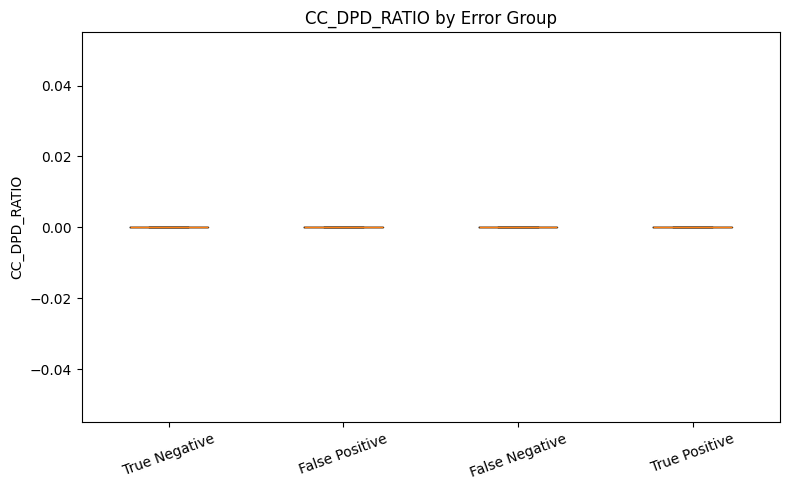

Saved: C:\Coding\Home-Credit-Default-Risk\outputs\figures\error_analysis\22_error_slice_CC_DPD_RATIO.png


In [37]:
extra_plot_candidates = [
    "BURO_ACTIVE_RATIO",
    "PREV_APPROVED_RATIO",
    "INS_LATE_RATIO",
    "POS_DPD_RATIO",
    "CC_DPD_RATIO",
]

extra_plot_candidates = [c for c in extra_plot_candidates if c in analysis_df.columns]

for i, feature in enumerate(extra_plot_candidates, start=20):
    temp = analysis_df[[feature, "ERROR_GROUP"]].dropna().copy()
    groups = ["True Negative", "False Positive", "False Negative", "True Positive"]
    data = [temp.loc[temp["ERROR_GROUP"] == g, feature].values for g in groups]

    plt.figure(figsize=(8, 5))
    plt.boxplot(data, labels=groups, showfliers=False)
    plt.title(f"{feature} by Error Group")
    plt.ylabel(feature)
    plt.xticks(rotation=20)
    plt.tight_layout()

    fig_path = ERROR_ANALYSIS_FIG_DIR / f"{i:02d}_error_slice_{feature}.png"
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.show()

    print("Saved:", fig_path)

In [2]:
import warnings
warnings.filterwarnings("ignore")

import re
import sys
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", "{:,.6f}".format)

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.config import (
    RAW_DATA_DIR,
    PROCESSED_DATA_DIR,
    FIGURES_DIR,
    REPORTS_DIR,
    SUBMISSIONS_DIR,
    MODELS_DIR,
    TARGET_COL,
    ID_COL,
)

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
SUBMISSIONS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

FINAL_FIG_DIR = FIGURES_DIR / "final_report"
FINAL_FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", project_root)
print("Final figure dir:", FINAL_FIG_DIR)

Project root: c:\Coding\Home-Credit-Default-Risk
Final figure dir: C:\Coding\Home-Credit-Default-Risk\outputs\figures\final_report


In [17]:
def find_optional_existing(base_dir, candidates):
    for name in candidates:
        path = base_dir / name
        if path.exists():
            return path
    return None

def parse_metric(text, pattern):
    match = re.search(pattern, text, flags=re.IGNORECASE)
    return float(match.group(1)) if match else np.nan

def parse_report(report_path):
    if report_path is None or not report_path.exists():
        return {
            "report_file": None,
            "mean_fold_auc": np.nan,
            "oof_auc": np.nan,
        }

    text = report_path.read_text(encoding="utf-8", errors="ignore")

    return {
        "report_file": report_path.name,
        "mean_fold_auc": parse_metric(text, r"Mean fold AUC:\s*([0-9.]+)"),
        "oof_auc": parse_metric(text, r"OOF AUC:\s*([0-9.]+)"),
    }

def to_markdown_table(df):
    cols = list(df.columns)
    lines = []
    lines.append("| " + " | ".join(cols) + " |")
    lines.append("| " + " | ".join(["---"] * len(cols)) + " |")
    for _, row in df.iterrows():
        vals = [str(row[c]) for c in cols]
        lines.append("| " + " | ".join(vals) + " |")
    return "\n".join(lines)

def clean_project_tree_text():
    return """Home-Credit-Default-Risk/
├── data/
│   ├── raw/
│   ├── processed/
│   └── sample/
├── notebooks/
│   ├── 01_data_audit.ipynb
│   ├── 02_eda_main_table.ipynb
│   ├── 03_baseline_main_table.ipynb
│   ├── 04_bureau_features.ipynb
│   ├── 05_model_with_bureau.ipynb
│   ├── 06_previous_application_features.ipynb
│   ├── 07_model_with_previous.ipynb
│   ├── 08_payment_history_features.ipynb
│   ├── 09_model_with_payments.ipynb
│   ├── 10_error_analysis.ipynb
│   └── 11_final_submission_and_report.ipynb
├── src/
│   ├── __init__.py
│   ├── config.py
│   ├── data_loader.py
│   ├── preprocessing.py
│   ├── train.py
│   ├── inference.py
│   ├── features_bureau.py
│   ├── features_previous.py
│   └── features_payments.py
├── outputs/
│   ├── figures/
│   ├── models/
│   ├── reports/
│   └── submissions/
├── README.md
├── requirements.txt
└── .gitignore"""

In [18]:
report_candidates = {
    "baseline": [
        "baseline_results.md",
    ],
    "bureau": [
        "model_v2_with_bureau.md",
    ],
    "bureau_previous": [
        "model_v3_bureau_previous.md",
    ],
    "payments": [
        "model_v4_with_payments.md",
        "full_model_results.md",
    ],
}

submission_candidates = {
    "baseline": [
        "baseline_main_table_catboost.csv",
        "baseline_main_table.csv",
    ],
    "bureau": [
        "model_v2_bureau.csv",
    ],
    "bureau_previous": [
        "model_v3_bureau_previous.csv",
    ],
    "payments": [
        "model_v4_with_payments.csv",
        "final_submission.csv",
    ],
}

report_paths = {
    name: find_optional_existing(REPORTS_DIR, candidates)
    for name, candidates in report_candidates.items()
}

submission_paths = {
    name: find_optional_existing(SUBMISSIONS_DIR, candidates)
    for name, candidates in submission_candidates.items()
}

print("Report files:")
for k, v in report_paths.items():
    print(f"{k:16} -> {v.name if v else 'NOT FOUND'}")

print("\nSubmission files:")
for k, v in submission_paths.items():
    print(f"{k:16} -> {v.name if v else 'NOT FOUND'}")

Report files:
baseline         -> baseline_results.md
bureau           -> model_v2_with_bureau.md
bureau_previous  -> model_v3_bureau_previous.md
payments         -> model_v4_with_payments.md

Submission files:
baseline         -> baseline_main_table_catboost.csv
bureau           -> model_v2_bureau.csv
bureau_previous  -> model_v3_bureau_previous.csv
payments         -> model_v4_with_payments.csv


In [19]:
comparison_rows = []

label_map = {
    "baseline": "Baseline (Main Table)",
    "bureau": "Main + Bureau",
    "bureau_previous": "Main + Bureau + Previous",
    "payments": "Main + Bureau + Previous + Payments",
}

order_map = {
    "baseline": 1,
    "bureau": 2,
    "bureau_previous": 3,
    "payments": 4,
}

fallback_scores = {
    "baseline": {"mean_fold_auc": 0.759922, "oof_auc": 0.759895},
    "bureau": {"mean_fold_auc": 0.765376, "oof_auc": 0.765354},
    "bureau_previous": {"mean_fold_auc": 0.772989, "oof_auc": 0.772974},
    "payments": {"mean_fold_auc": np.nan, "oof_auc": np.nan},
}

for key in ["baseline", "bureau", "bureau_previous", "payments"]:
    parsed = parse_report(report_paths[key])

    mean_fold_auc = parsed["mean_fold_auc"]
    oof_auc = parsed["oof_auc"]

    if pd.isna(mean_fold_auc):
        mean_fold_auc = fallback_scores[key]["mean_fold_auc"]
    if pd.isna(oof_auc):
        oof_auc = fallback_scores[key]["oof_auc"]

    comparison_rows.append({
        "order": order_map[key],
        "model_key": key,
        "model_name": label_map[key],
        "mean_fold_auc": mean_fold_auc,
        "oof_auc": oof_auc,
        "report_file": parsed["report_file"],
        "submission_file": submission_paths[key].name if submission_paths[key] else None,
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values("order").reset_index(drop=True)

comparison_df["lift_vs_previous"] = comparison_df["oof_auc"].diff()
comparison_df["lift_vs_baseline"] = comparison_df["oof_auc"] - comparison_df.loc[comparison_df["model_key"] == "baseline", "oof_auc"].iloc[0]

display(comparison_df)

,order,model_key,model_name,mean_fold_auc,oof_auc,report_file,submission_file,lift_vs_previous,lift_vs_baseline
0,1,baseline,Baseline (Main Table),0.759922,0.759895,baseline_results.md,baseline_main_table_catboost.csv,NaN,0.000000
1,2,bureau,Main + Bureau,0.765376,0.765354,model_v2_with_bureau.md,model_v2_bureau.csv,0.005459,0.005459
2,3,bureau_previous,Main + Bureau + Previous,0.772989,0.772974,model_v3_bureau_previous.md,model_v3_bureau_previous.csv,0.007620,0.013079
3,4,payments,Main + Bureau + Previous + Payments,0.785389,0.785274,model_v4_with_payments.md,model_v4_with_payments.csv,0.012300,0.025379


In [20]:
comparison_csv_path = REPORTS_DIR / "final_model_comparison.csv"
comparison_df.to_csv(comparison_csv_path, index=False)

print("Saved:", comparison_csv_path)

Saved: C:\Coding\Home-Credit-Default-Risk\outputs\reports\final_model_comparison.csv


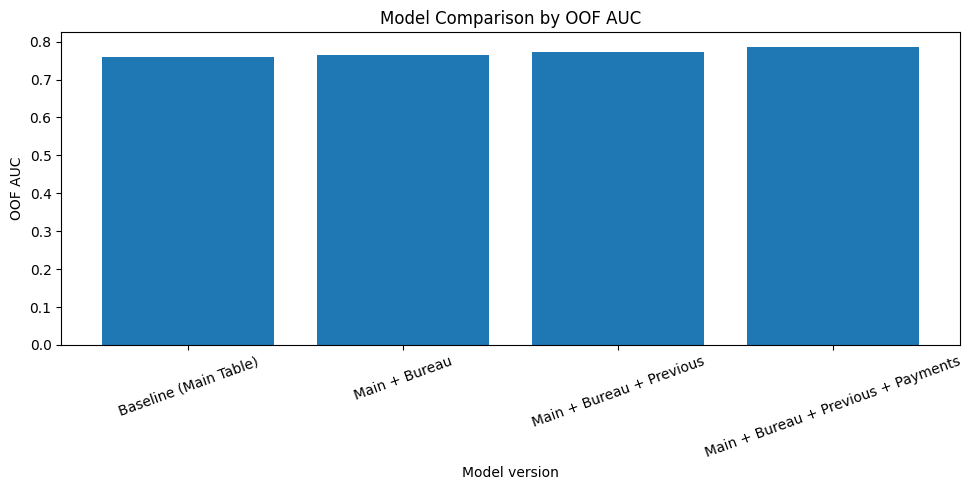

Saved: C:\Coding\Home-Credit-Default-Risk\outputs\figures\final_report\01_model_comparison.png


In [21]:
plot_df = comparison_df.copy()

plt.figure(figsize=(10, 5))
plt.bar(plot_df["model_name"], plot_df["oof_auc"])
plt.title("Model Comparison by OOF AUC")
plt.xlabel("Model version")
plt.ylabel("OOF AUC")
plt.xticks(rotation=20)
plt.tight_layout()

comparison_fig_path = FINAL_FIG_DIR / "01_model_comparison.png"
plt.savefig(comparison_fig_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", comparison_fig_path)

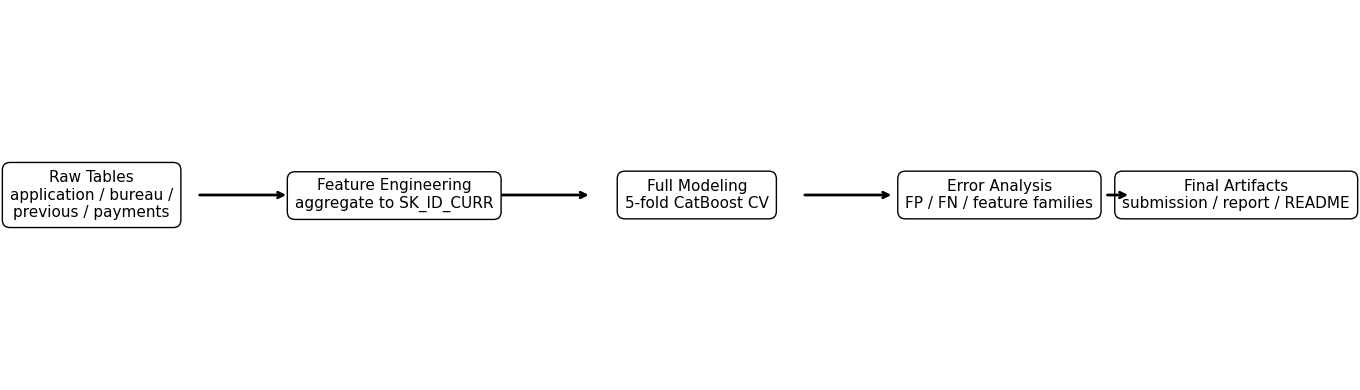

Saved: C:\Coding\Home-Credit-Default-Risk\outputs\figures\final_report\02_project_pipeline_overview.png


In [22]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.axis("off")

boxes = [
    (0.05, 0.5, "Raw Tables\napplication / bureau /\nprevious / payments"),
    (0.28, 0.5, "Feature Engineering\naggregate to SK_ID_CURR"),
    (0.51, 0.5, "Full Modeling\n5-fold CatBoost CV"),
    (0.74, 0.5, "Error Analysis\nFP / FN / feature families"),
    (0.92, 0.5, "Final Artifacts\nsubmission / report / README"),
]

for x, y, text in boxes:
    ax.text(
        x, y, text,
        ha="center", va="center",
        fontsize=11,
        bbox=dict(boxstyle="round,pad=0.5", edgecolor="black", facecolor="white")
    )

for i in range(len(boxes) - 1):
    x1 = boxes[i][0] + 0.08
    x2 = boxes[i + 1][0] - 0.08
    ax.annotate("", xy=(x2, 0.5), xytext=(x1, 0.5),
                arrowprops=dict(arrowstyle="->", lw=2))

pipeline_fig_path = FINAL_FIG_DIR / "02_project_pipeline_overview.png"
plt.tight_layout()
plt.savefig(pipeline_fig_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", pipeline_fig_path)

In [23]:
model_files = sorted([p.name for p in MODELS_DIR.iterdir() if p.is_file()])

print("Model files found:")
for f in model_files:
    print("-", f)

source_model_path = find_optional_existing(
    MODELS_DIR,
    [
        "final_model.joblib",
        "model_v4_with_payments_fold5.joblib",
    ],
)

final_model_path = MODELS_DIR / "final_model.joblib"

if source_model_path is not None and source_model_path.exists():
    if source_model_path.resolve() != final_model_path.resolve():
        shutil.copyfile(source_model_path, final_model_path)
    print("Final model artifact:", final_model_path)
else:
    print("No model artifact found in outputs/models yet.")
    print("Recommended: save or copy one trained model as outputs/models/final_model.joblib")

Model files found:
- model_v4_with_payments_fold5.joblib
Final model artifact: C:\Coding\Home-Credit-Default-Risk\outputs\models\final_model.joblib


In [24]:
tree_text = clean_project_tree_text()
print(tree_text)

Home-Credit-Default-Risk/
├── data/
│   ├── raw/
│   ├── processed/
│   └── sample/
├── notebooks/
│   ├── 01_data_audit.ipynb
│   ├── 02_eda_main_table.ipynb
│   ├── 03_baseline_main_table.ipynb
│   ├── 04_bureau_features.ipynb
│   ├── 05_model_with_bureau.ipynb
│   ├── 06_previous_application_features.ipynb
│   ├── 07_model_with_previous.ipynb
│   ├── 08_payment_history_features.ipynb
│   ├── 09_model_with_payments.ipynb
│   ├── 10_error_analysis.ipynb
│   └── 11_final_submission_and_report.ipynb
├── src/
│   ├── __init__.py
│   ├── config.py
│   ├── data_loader.py
│   ├── preprocessing.py
│   ├── train.py
│   ├── inference.py
│   ├── features_bureau.py
│   ├── features_previous.py
│   └── features_payments.py
├── outputs/
│   ├── figures/
│   ├── models/
│   ├── reports/
│   └── submissions/
├── README.md
├── requirements.txt
└── .gitignore


In [25]:
readme_results_df = comparison_df[["model_name", "mean_fold_auc", "oof_auc", "lift_vs_previous", "lift_vs_baseline"]].copy()

for col in ["mean_fold_auc", "oof_auc", "lift_vs_previous", "lift_vs_baseline"]:
    readme_results_df[col] = readme_results_df[col].map(lambda x: f"{x:.6f}" if pd.notnull(x) else "N/A")

display(readme_results_df)

,model_name,mean_fold_auc,oof_auc,lift_vs_previous,lift_vs_baseline
0,Baseline (Main Table),0.759922,0.759895,N/A,0.000000
1,Main + Bureau,0.765376,0.765354,0.005459,0.005459
2,Main + Bureau + Previous,0.772989,0.772974,0.007620,0.013079
3,Main + Bureau + Previous + Payments,0.785389,0.785274,0.012300,0.025379


In [26]:
best_row = comparison_df.sort_values("oof_auc", ascending=False).iloc[0]
best_model_key = best_row["model_key"]
best_submission_path = submission_paths.get(best_model_key)

print("Best model:", best_row["model_name"])
print("Best OOF AUC:", best_row["oof_auc"])
print("Best submission source:", best_submission_path)

final_submission_path = SUBMISSIONS_DIR / "final_submission.csv"

if best_submission_path is not None and best_submission_path.exists():
    shutil.copyfile(best_submission_path, final_submission_path)
    print("Saved final submission:", final_submission_path)
else:
    print("No source submission found to copy.")

Best model: Main + Bureau + Previous + Payments
Best OOF AUC: 0.785274
Best submission source: C:\Coding\Home-Credit-Default-Risk\outputs\submissions\model_v4_with_payments.csv
Saved final submission: C:\Coding\Home-Credit-Default-Risk\outputs\submissions\final_submission.csv


In [27]:
results_table_md = to_markdown_table(readme_results_df)

problem_statement = """
Home Credit Default Risk is a binary classification problem: predict the probability that a loan applicant will have repayment difficulties (`TARGET=1`). The competition metric is ROC-AUC, so the project focuses on ranking risky applicants correctly rather than maximizing plain accuracy.
""".strip()

dataset_structure = """
The dataset is relational, not a single flat table. `application_train` and `application_test` are the core modeling tables, while `bureau`, `bureau_balance`, `previous_application`, `installments_payments`, `POS_CASH_balance`, and `credit_card_balance` provide historical credit behavior. Because these auxiliary tables contain one-to-many and monthly-history records, they must be aggregated to the customer level (`SK_ID_CURR`) before modeling.
""".strip()

methodology = """
1. Audit the dataset structure and join keys.
2. Perform EDA on the main application table.
3. Build a baseline model using only the main table.
4. Engineer relational features from bureau history.
5. Add previous application features.
6. Add payment-history features from installments, POS cash, and credit card balance.
7. Train a full 5-fold CatBoost model and evaluate with OOF ROC-AUC.
8. Perform error analysis on false positives, false negatives, and feature-family importance.
""".strip()

feature_engineering_overview = """
Feature engineering is the core of this project. I created:
- **Main application features**: cleaned anomalies and useful ratios
- **Bureau features**: external credit history and active/closed debt behavior
- **Previous application features**: approval/refusal behavior and prior loan application patterns
- **Payment-history features**: installment lateness, POS delinquency, and revolving credit card behavior

The key idea is to aggregate all history tables to the same customer level before merging.
""".strip()

how_to_reproduce = """
1. Clone the repository.
2. Place the full Kaggle competition data into `data/raw/`.
3. Install dependencies from `requirements.txt`.
4. Run notebooks in order:
   - `01_data_audit.ipynb`
   - `02_eda_main_table.ipynb`
   - `03_baseline_main_table.ipynb`
   - `04_bureau_features.ipynb`
   - `05_model_with_bureau.ipynb`
   - `06_previous_application_features.ipynb`
   - `07_model_with_previous.ipynb`
   - `08_payment_history_features.ipynb`
   - `09_model_with_payments.ipynb`
   - `10_error_analysis.ipynb`
   - `11_final_submission_and_report.ipynb`
5. Use the generated file in `outputs/submissions/final_submission.csv` for Kaggle submission.
""".strip()

In [28]:
final_report_path = REPORTS_DIR / "final_project_summary.md"

final_report_lines = [
    "# Final Project Summary",
    "",
    "## Best Model",
    f"- Best model: {best_row['model_name']}",
    f"- Best OOF AUC: {best_row['oof_auc']:.6f}" if pd.notnull(best_row["oof_auc"]) else "- Best OOF AUC: N/A",
    f"- Final submission: {final_submission_path}" if final_submission_path.exists() else "- Final submission: not created",
    f"- Final model artifact: {final_model_path}" if final_model_path.exists() else "- Final model artifact: not created",
    "",
    "## Model Comparison",
    results_table_md,
    "",
    "## Generated Artifacts",
    f"- Comparison CSV: {comparison_csv_path}",
    f"- Comparison figure: {comparison_fig_path}",
    f"- Pipeline figure: {pipeline_fig_path}",
    f"- README: {project_root / 'README.md'}",
]

final_report_path.write_text("\n".join(final_report_lines), encoding="utf-8")

print("Saved:", final_report_path)
print(final_report_path.read_text(encoding="utf-8")[:3000])

Saved: C:\Coding\Home-Credit-Default-Risk\outputs\reports\final_project_summary.md
# Final Project Summary

## Best Model
- Best model: Main + Bureau + Previous + Payments
- Best OOF AUC: 0.785274
- Final submission: C:\Coding\Home-Credit-Default-Risk\outputs\submissions\final_submission.csv
- Final model artifact: C:\Coding\Home-Credit-Default-Risk\outputs\models\final_model.joblib

## Model Comparison
| model_name | mean_fold_auc | oof_auc | lift_vs_previous | lift_vs_baseline |
| --- | --- | --- | --- | --- |
| Baseline (Main Table) | 0.759922 | 0.759895 | N/A | 0.000000 |
| Main + Bureau | 0.765376 | 0.765354 | 0.005459 | 0.005459 |
| Main + Bureau + Previous | 0.772989 | 0.772974 | 0.007620 | 0.013079 |
| Main + Bureau + Previous + Payments | 0.785389 | 0.785274 | 0.012300 | 0.025379 |

## Generated Artifacts
- Comparison CSV: C:\Coding\Home-Credit-Default-Risk\outputs\reports\final_model_comparison.csv
- Comparison figure: C:\Coding\Home-Credit-Default-Risk\outputs\figures\final_

In [29]:
readme_path = project_root / "README.md"

readme_lines = [
    "# Home Credit Default Risk",
    "",
    "## 1. Problem Statement",
    problem_statement,
    "",
    "## 2. Dataset Structure",
    dataset_structure,
    "",
    "## 3. Project Structure",
    "```text",
    tree_text,
    "```",
    "",
    "## 4. Methodology",
    methodology,
    "",
    "## 5. Feature Engineering Overview",
    feature_engineering_overview,
    "",
    "## 6. Modeling Results",
    "Model comparison based on cross-validated OOF ROC-AUC:",
    "",
    results_table_md,
    "",
    f"Best model: **{best_row['model_name']}**",
    f"Best OOF AUC: **{best_row['oof_auc']:.6f}**" if pd.notnull(best_row["oof_auc"]) else "Best OOF AUC: **N/A**",
    "",
    "Generated figures:",
    f"- `outputs/figures/final_report/{comparison_fig_path.name}`",
    f"- `outputs/figures/final_report/{pipeline_fig_path.name}`",
    "",
    "## 7. How to Reproduce",
    how_to_reproduce,
    "",
    "## Notes",
    "- Do not commit raw data to GitHub.",
    "- The dataset is relational and requires aggregation from one-to-many history tables to the customer level (`SK_ID_CURR`).",
    "- The strongest gains in this project come from relational feature engineering, not from trying many different model families.",
]

readme_path.write_text("\n".join(readme_lines), encoding="utf-8")

print("Saved:", readme_path)
print(readme_path.read_text(encoding="utf-8")[:4000])

Saved: c:\Coding\Home-Credit-Default-Risk\README.md
# Home Credit Default Risk

## 1. Problem Statement
Home Credit Default Risk is a binary classification problem: predict the probability that a loan applicant will have repayment difficulties (`TARGET=1`). The competition metric is ROC-AUC, so the project focuses on ranking risky applicants correctly rather than maximizing plain accuracy.

## 2. Dataset Structure
The dataset is relational, not a single flat table. `application_train` and `application_test` are the core modeling tables, while `bureau`, `bureau_balance`, `previous_application`, `installments_payments`, `POS_CASH_balance`, and `credit_card_balance` provide historical credit behavior. Because these auxiliary tables contain one-to-many and monthly-history records, they must be aggregated to the customer level (`SK_ID_CURR`) before modeling.

## 3. Project Structure
```text
Home-Credit-Default-Risk/
├── data/
│   ├── raw/
│   ├── processed/
│   └── sample/
├── notebooks/
│ 

In [30]:
final_files = [
    comparison_csv_path,
    comparison_fig_path,
    pipeline_fig_path,
    final_report_path,
    readme_path,
]

if final_submission_path.exists():
    final_files.append(final_submission_path)

print("Final generated files:")
for path in final_files:
    print("-", path, "| exists =", path.exists())

Final generated files:
- C:\Coding\Home-Credit-Default-Risk\outputs\reports\final_model_comparison.csv | exists = True
- C:\Coding\Home-Credit-Default-Risk\outputs\figures\final_report\01_model_comparison.png | exists = True
- C:\Coding\Home-Credit-Default-Risk\outputs\figures\final_report\02_project_pipeline_overview.png | exists = True
- C:\Coding\Home-Credit-Default-Risk\outputs\reports\final_project_summary.md | exists = True
- c:\Coding\Home-Credit-Default-Risk\README.md | exists = True
- C:\Coding\Home-Credit-Default-Risk\outputs\submissions\final_submission.csv | exists = True
